# 06. Baselines con features de subgrafos

Este notebook corresponde al Nivel 5 de la metodología. Su objetivo es entrenar modelos clásicos utilizando features estructurales derivadas de subgrafos k-hop.

A diferencia del análisis descriptivo del Nivel 4, en este nivel se evita usar variables derivadas directamente de etiquetas vecinas, como `ratio_illicit_neighbors` o `num_illicit_neighbors`, para prevenir fuga de información.

Se evaluarán dos enfoques:

1. Modelos usando solo features estructurales de subgrafos.
2. Modelos usando features originales del dataset Elliptic más features estructurales de subgrafos.

Los resultados se compararán contra los baselines clásicos del Nivel 2.

In [1]:
# Imports y rutas
import sys
from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from aml_gnn.utils.paths import INTERIM_DIR, PROCESSED_DIR, REPORTS_DIR, MODELS_DIR, EXPERIMENTS_DIR
from aml_gnn.evaluation.metrics import evaluate_binary_classifier

print("PROJECT_ROOT:", PROJECT_ROOT)
print("INTERIM_DIR:", INTERIM_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("REPORTS_DIR:", REPORTS_DIR)

PROJECT_ROOT: /home/lucho/aml-gnn-tesis
INTERIM_DIR: /home/lucho/aml-gnn-tesis/data/interim/elliptic
PROCESSED_DIR: /home/lucho/aml-gnn-tesis/data/processed/elliptic
REPORTS_DIR: /home/lucho/aml-gnn-tesis/reports


In [2]:
# Cargando features de subgrafos y nodos
subgraph_features_path = PROCESSED_DIR / "subgraph_features_labeled.parquet"
nodes_path = INTERIM_DIR / "nodes_with_graph_features.parquet"

subgraph_features_df = pd.read_parquet(subgraph_features_path)
nodes_df = pd.read_parquet(nodes_path)

print("Subgraph features:", subgraph_features_df.shape)
print("Nodes:", nodes_df.shape)

subgraph_features_df.head()

Subgraph features: (93128, 21)
Nodes: (203769, 171)


,center_txId,k,direction,subgraph_num_nodes,subgraph_num_edges,subgraph_density,center_in_degree,center_out_degree,center_total_degree,num_licit_neighbors,...,num_unknown_neighbors,ratio_licit_neighbors,ratio_illicit_neighbors,ratio_unknown_neighbors,avg_neighbor_total_degree,max_neighbor_total_degree,fan_in_out_ratio,label,target,timestep
0,232438397,1,both,162,169,0.006480,160,1,161,61,...,99,0.378882,0.006211,0.614907,2.757764,28,160.0,licit,0,1
1,232438397,2,both,420,464,0.002637,160,1,161,147,...,271,0.350835,0.002387,0.646778,3.918854,289,160.0,licit,0,1
2,232029206,1,both,61,62,0.016940,59,1,60,23,...,37,0.383333,0.000000,0.616667,2.666667,8,59.0,licit,0,1
3,232029206,2,both,154,162,0.006875,59,1,60,58,...,95,0.379085,0.000000,0.620915,3.588235,143,59.0,licit,0,1
4,232344069,1,both,3,2,0.333333,0,2,2,2,...,0,1.000000,0.000000,0.000000,1.500000,2,0.0,licit,0,1


In [4]:
# Definiendo features estructurales válidas

# Features estructurales permitidas para modelado predictivo.
# No se incluyen variables basadas en etiquetas vecinas para evitar fuga de información.

strict_subgraph_feature_cols = [
    "subgraph_num_nodes",
    "subgraph_num_edges",
    "subgraph_density",
    "center_in_degree",
    "center_out_degree",
    "center_total_degree",
    "avg_neighbor_total_degree",
    "max_neighbor_total_degree",
    "fan_in_out_ratio",
]

strict_subgraph_feature_cols

['subgraph_num_nodes',
 'subgraph_num_edges',
 'subgraph_density',
 'center_in_degree',
 'center_out_degree',
 'center_total_degree',
 'avg_neighbor_total_degree',
 'max_neighbor_total_degree',
 'fan_in_out_ratio']

In [5]:
# Convertiendo de formato largo a formato ancho
subgraph_model_df = subgraph_features_df[
    ["center_txId", "label", "target", "timestep", "k"] + strict_subgraph_feature_cols
].copy()

subgraph_wide_df = subgraph_model_df.pivot_table(
    index=["center_txId", "label", "target", "timestep"],
    columns="k",
    values=strict_subgraph_feature_cols,
    aggfunc="first"
)

subgraph_wide_df.columns = [
    f"{feature}_k{int(k)}"
    for feature, k in subgraph_wide_df.columns
]

subgraph_wide_df = subgraph_wide_df.reset_index()

print("Subgraph wide:", subgraph_wide_df.shape)
subgraph_wide_df.head()

Subgraph wide: (46564, 22)


,center_txId,label,target,timestep,avg_neighbor_total_degree_k1,avg_neighbor_total_degree_k2,center_in_degree_k1,center_in_degree_k2,center_out_degree_k1,center_out_degree_k2,...,fan_in_out_ratio_k1,fan_in_out_ratio_k2,max_neighbor_total_degree_k1,max_neighbor_total_degree_k2,subgraph_density_k1,subgraph_density_k2,subgraph_num_edges_k1,subgraph_num_edges_k2,subgraph_num_nodes_k1,subgraph_num_nodes_k2
0,2534,licit,0,6,6.666667,3.050000,0,0,3,3,...,0.000000,0.000000,18,18,0.250000,0.047619,3,20,4,21
1,3181,licit,0,34,3.911504,3.025189,1,1,112,112,...,0.008929,0.008929,47,53,0.009082,0.002867,117,453,114,398
2,6418,licit,0,48,2.909091,4.923636,97,97,2,2,...,48.500000,48.500000,100,121,0.010303,0.004084,102,310,100,276
3,7952,licit,0,48,7.250000,3.079460,1,1,99,99,...,0.010101,0.010101,99,105,0.011188,0.001703,113,759,101,668
4,9351,licit,0,48,29.000000,6.103448,1,1,0,0,...,0.000000,0.000000,29,54,0.500000,0.037931,1,33,2,30


In [6]:
# Validando distribución de clases
class_check = (
    subgraph_wide_df["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)

class_check["percentage"] = (
    class_check["count"] / class_check["count"].sum() * 100
).round(2)

class_check

,label,count,percentage
0,licit,42019,90.24
1,illicit,4545,9.76


In [7]:
# Creando split temporal
unique_timesteps = np.array(sorted(subgraph_wide_df["timestep"].unique()))

n_timesteps = len(unique_timesteps)
train_end_idx = int(n_timesteps * 0.70)
val_end_idx = int(n_timesteps * 0.85)

train_timesteps = unique_timesteps[:train_end_idx]
val_timesteps = unique_timesteps[train_end_idx:val_end_idx]
test_timesteps = unique_timesteps[val_end_idx:]

def assign_split(timestep):
    if timestep in train_timesteps:
        return "train"
    if timestep in val_timesteps:
        return "val"
    return "test"

subgraph_wide_df["split"] = subgraph_wide_df["timestep"].apply(assign_split)

split_summary = (
    subgraph_wide_df
    .groupby(["split", "label"])
    .size()
    .reset_index(name="count")
)

split_pivot = split_summary.pivot(
    index="split",
    columns="label",
    values="count"
).fillna(0).astype(int)

split_pivot["total"] = split_pivot.sum(axis=1)
split_pivot["illicit_percentage"] = (
    split_pivot["illicit"] / split_pivot["total"] * 100
).round(2)

split_pivot

label,illicit,licit,total,illicit_percentage
split,,,,
test,408,8433,8841,4.61
train,3462,26432,29894,11.58
val,675,7154,7829,8.62


## Modelo A: Subgraph-only

In [8]:
# Creando matrices subgraph-only
subgraph_feature_cols_wide = [
    col for col in subgraph_wide_df.columns
    if any(col.startswith(base_col + "_k") for base_col in strict_subgraph_feature_cols)
]

print("Número de features de subgrafos:", len(subgraph_feature_cols_wide))
subgraph_feature_cols_wide

Número de features de subgrafos: 18


['avg_neighbor_total_degree_k1',
 'avg_neighbor_total_degree_k2',
 'center_in_degree_k1',
 'center_in_degree_k2',
 'center_out_degree_k1',
 'center_out_degree_k2',
 'center_total_degree_k1',
 'center_total_degree_k2',
 'fan_in_out_ratio_k1',
 'fan_in_out_ratio_k2',
 'max_neighbor_total_degree_k1',
 'max_neighbor_total_degree_k2',
 'subgraph_density_k1',
 'subgraph_density_k2',
 'subgraph_num_edges_k1',
 'subgraph_num_edges_k2',
 'subgraph_num_nodes_k1',
 'subgraph_num_nodes_k2']

In [9]:
# Train, validation y test
train_df = subgraph_wide_df[subgraph_wide_df["split"] == "train"].copy()
val_df = subgraph_wide_df[subgraph_wide_df["split"] == "val"].copy()
test_df = subgraph_wide_df[subgraph_wide_df["split"] == "test"].copy()

X_train_sub = train_df[subgraph_feature_cols_wide]
y_train_sub = train_df["target"]

X_val_sub = val_df[subgraph_feature_cols_wide]
y_val_sub = val_df["target"]

X_test_sub = test_df[subgraph_feature_cols_wide]
y_test_sub = test_df["target"]

print("X_train_sub:", X_train_sub.shape)
print("X_val_sub:", X_val_sub.shape)
print("X_test_sub:", X_test_sub.shape)

X_train_sub: (29894, 18)
X_val_sub: (7829, 18)
X_test_sub: (8841, 18)


In [10]:
# Random Forest subgraph-only
rf_sub_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_sub_model.fit(X_train_sub, y_train_sub)

val_score_rf_sub = rf_sub_model.predict_proba(X_val_sub)[:, 1]
test_score_rf_sub = rf_sub_model.predict_proba(X_test_sub)[:, 1]

rf_sub_val_metrics = evaluate_binary_classifier(y_val_sub.to_numpy(), val_score_rf_sub)
rf_sub_test_metrics = evaluate_binary_classifier(y_test_sub.to_numpy(), test_score_rf_sub)

rf_sub_test_metrics

{'accuracy': 0.8565773102590205,
 'precision': 0.08171206225680934,
 'recall': 0.20588235294117646,
 'f1': 0.116991643454039,
 'pr_auc': 0.06988285525698029,
 'roc_auc': 0.6410376020442565,
 'confusion_matrix': [[7489, 944], [324, 84]],
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.96      0.89      0.92      8433\n           1       0.08      0.21      0.12       408\n\n    accuracy                           0.86      8841\n   macro avg       0.52      0.55      0.52      8841\nweighted avg       0.92      0.86      0.88      8841\n',
 'recall_at_50': np.float64(0.004901960784313725),
 'recall_at_100': np.float64(0.024509803921568627),
 'recall_at_500': np.float64(0.09803921568627451),
 'recall_at_1000': np.float64(0.17647058823529413)}

In [11]:
# XGBoost subgraph-only
num_negative = int((y_train_sub == 0).sum())
num_positive = int((y_train_sub == 1).sum())

scale_pos_weight_sub = num_negative / num_positive

xgb_sub_model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight_sub,
    random_state=42,
    n_jobs=-1
)

xgb_sub_model.fit(
    X_train_sub,
    y_train_sub,
    eval_set=[(X_val_sub, y_val_sub)],
    verbose=False
)

val_score_xgb_sub = xgb_sub_model.predict_proba(X_val_sub)[:, 1]
test_score_xgb_sub = xgb_sub_model.predict_proba(X_test_sub)[:, 1]

xgb_sub_val_metrics = evaluate_binary_classifier(y_val_sub.to_numpy(), val_score_xgb_sub)
xgb_sub_test_metrics = evaluate_binary_classifier(y_test_sub.to_numpy(), test_score_xgb_sub)

xgb_sub_test_metrics

{'accuracy': 0.783961090374392,
 'precision': 0.10095642933049948,
 'recall': 0.46568627450980393,
 'f1': 0.16593886462882096,
 'pr_auc': 0.11331758369288913,
 'roc_auc': 0.7300582096944078,
 'confusion_matrix': [[6741, 1692], [218, 190]],
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.97      0.80      0.88      8433\n           1       0.10      0.47      0.17       408\n\n    accuracy                           0.78      8841\n   macro avg       0.53      0.63      0.52      8841\nweighted avg       0.93      0.78      0.84      8841\n',
 'recall_at_50': np.float64(0.022058823529411766),
 'recall_at_100': np.float64(0.061274509803921566),
 'recall_at_500': np.float64(0.16666666666666666),
 'recall_at_1000': np.float64(0.2696078431372549)}

## Modelo B: Original + subgraph

In [12]:
# Construyendo dataset combinado
original_feature_cols = [
    col for col in nodes_df.columns
    if col.startswith("f_")
]

nodes_original_df = nodes_df[
    ["txId"] + original_feature_cols
].copy()

combined_df = subgraph_wide_df.merge(
    nodes_original_df,
    left_on="center_txId",
    right_on="txId",
    how="left"
)

print("Combined:", combined_df.shape)
combined_df.head()

Combined: (46564, 189)


,center_txId,label,target,timestep,avg_neighbor_total_degree_k1,avg_neighbor_total_degree_k2,center_in_degree_k1,center_in_degree_k2,center_out_degree_k1,center_out_degree_k2,...,f_155,f_156,f_157,f_158,f_159,f_160,f_161,f_162,f_163,f_164
0,2534,licit,0,6,6.666667,3.050000,0,0,3,3,...,1.228858,0.379357,0.955101,0.459257,-0.098889,-0.087490,-0.099080,-0.122137,-0.379970,-0.379288
1,3181,licit,0,34,3.911504,3.025189,1,1,112,112,...,1.348450,1.590664,0.059948,0.113967,-0.098889,1.969527,0.037532,-0.131010,0.006994,0.017772
2,6418,licit,0,48,2.909091,4.923636,97,97,2,2,...,0.433960,0.168508,-0.197237,0.303447,-0.098889,0.931406,1.041565,0.371499,0.790060,0.779125
3,7952,licit,0,48,7.250000,3.079460,1,1,99,99,...,0.823581,0.850443,0.321431,0.268810,-0.098889,1.162100,0.485146,0.303509,-0.553520,-0.578865
4,9351,licit,0,48,29.000000,6.103448,1,1,0,0,...,-0.569626,0.641566,1.461330,1.461369,-0.098889,0.662264,1.728088,1.539269,1.519700,1.521399


In [ ]:
# Definiendo features combinadas
combined_feature_cols = original_feature_cols + subgraph_feature_cols_wide

print("Features originales:", len(original_feature_cols))
print("Features de subgrafos:", len(subgraph_feature_cols_wide))
print("Features combinadas:", len(combined_feature_cols))

Features originales: 165
Features de subgrafos: 18
Features combinadas: 183


In [14]:
# Creando matrices combinadas
train_combined_df = combined_df[combined_df["split"] == "train"].copy()
val_combined_df = combined_df[combined_df["split"] == "val"].copy()
test_combined_df = combined_df[combined_df["split"] == "test"].copy()

X_train_combined = train_combined_df[combined_feature_cols]
y_train_combined = train_combined_df["target"]

X_val_combined = val_combined_df[combined_feature_cols]
y_val_combined = val_combined_df["target"]

X_test_combined = test_combined_df[combined_feature_cols]
y_test_combined = test_combined_df["target"]

print("X_train_combined:", X_train_combined.shape)
print("X_val_combined:", X_val_combined.shape)
print("X_test_combined:", X_test_combined.shape)

X_train_combined: (29894, 183)
X_val_combined: (7829, 183)
X_test_combined: (8841, 183)


In [15]:
# Random Forest original + subgraph
rf_combined_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_combined_model.fit(X_train_combined, y_train_combined)

val_score_rf_combined = rf_combined_model.predict_proba(X_val_combined)[:, 1]
test_score_rf_combined = rf_combined_model.predict_proba(X_test_combined)[:, 1]

rf_combined_val_metrics = evaluate_binary_classifier(
    y_val_combined.to_numpy(),
    val_score_rf_combined
)

rf_combined_test_metrics = evaluate_binary_classifier(
    y_test_combined.to_numpy(),
    test_score_rf_combined
)

rf_combined_test_metrics

{'accuracy': 0.9740979527202805,
 'precision': 0.958974358974359,
 'recall': 0.4583333333333333,
 'f1': 0.6202321724709784,
 'pr_auc': 0.5480719796076682,
 'roc_auc': 0.8643729814942697,
 'confusion_matrix': [[8425, 8], [221, 187]],
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.97      1.00      0.99      8433\n           1       0.96      0.46      0.62       408\n\n    accuracy                           0.97      8841\n   macro avg       0.97      0.73      0.80      8841\nweighted avg       0.97      0.97      0.97      8841\n',
 'recall_at_50': np.float64(0.12254901960784313),
 'recall_at_100': np.float64(0.24509803921568626),
 'recall_at_500': np.float64(0.4852941176470588),
 'recall_at_1000': np.float64(0.5318627450980392)}

In [16]:
# XGBoost original + subgraph
num_negative_combined = int((y_train_combined == 0).sum())
num_positive_combined = int((y_train_combined == 1).sum())

scale_pos_weight_combined = num_negative_combined / num_positive_combined

xgb_combined_model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight_combined,
    random_state=42,
    n_jobs=-1
)

xgb_combined_model.fit(
    X_train_combined,
    y_train_combined,
    eval_set=[(X_val_combined, y_val_combined)],
    verbose=False
)

val_score_xgb_combined = xgb_combined_model.predict_proba(X_val_combined)[:, 1]
test_score_xgb_combined = xgb_combined_model.predict_proba(X_test_combined)[:, 1]

xgb_combined_val_metrics = evaluate_binary_classifier(
    y_val_combined.to_numpy(),
    val_score_xgb_combined
)

xgb_combined_test_metrics = evaluate_binary_classifier(
    y_test_combined.to_numpy(),
    test_score_xgb_combined
)

xgb_combined_test_metrics

{'accuracy': 0.957018436828413,
 'precision': 0.5380434782608695,
 'recall': 0.4852941176470588,
 'f1': 0.5103092783505154,
 'pr_auc': 0.5502550550137272,
 'roc_auc': 0.8608908047981436,
 'confusion_matrix': [[8263, 170], [210, 198]],
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.98      0.98      0.98      8433\n           1       0.54      0.49      0.51       408\n\n    accuracy                           0.96      8841\n   macro avg       0.76      0.73      0.74      8841\nweighted avg       0.96      0.96      0.96      8841\n',
 'recall_at_50': np.float64(0.12254901960784313),
 'recall_at_100': np.float64(0.23774509803921567),
 'recall_at_500': np.float64(0.5),
 'recall_at_1000': np.float64(0.553921568627451)}

## Comparación contra modelos anteriores

In [17]:
# Cargando métricas anteriores
baseline_metrics_path = REPORTS_DIR / "metrics" / "baseline_metrics.json"
gnn_metrics_path = REPORTS_DIR / "metrics" / "gnn_node_metrics.json"
gnn_full_metrics_path = REPORTS_DIR / "metrics" / "gnn_node_metrics_full_context.json"

with open(baseline_metrics_path, "r", encoding="utf-8") as file:
    baseline_metrics = json.load(file)

with open(gnn_metrics_path, "r", encoding="utf-8") as file:
    gnn_metrics = json.load(file)

with open(gnn_full_metrics_path, "r", encoding="utf-8") as file:
    gnn_full_metrics = json.load(file)

logreg_test_metrics = baseline_metrics["logistic_regression"]["test"]
rf_test_metrics = baseline_metrics["random_forest"]["test"]
xgb_test_metrics = baseline_metrics["xgboost"]["test"]

gcn_3a_test_metrics = gnn_metrics["gcn"]["test"]
sage_3a_test_metrics = gnn_metrics["graphsage"]["test"]

gcn_3b_test_metrics = gnn_full_metrics["gcn_full_context"]["test"]
sage_3b_test_metrics = gnn_full_metrics["graphsage_full_context"]["test"]

In [18]:
# Tabla comparativa final
def compact_metrics(model_name, metrics_dict, split="test"):
    return {
        "model": model_name,
        "split": split,
        "accuracy": metrics_dict["accuracy"],
        "precision": metrics_dict["precision"],
        "recall": metrics_dict["recall"],
        "f1": metrics_dict["f1"],
        "pr_auc": metrics_dict["pr_auc"],
        "roc_auc": metrics_dict["roc_auc"],
        "recall_at_50": metrics_dict["recall_at_50"],
        "recall_at_100": metrics_dict["recall_at_100"],
        "recall_at_500": metrics_dict["recall_at_500"],
        "recall_at_1000": metrics_dict["recall_at_1000"],
    }


level_5_rows = [
    compact_metrics("Logistic Regression baseline", logreg_test_metrics),
    compact_metrics("Random Forest baseline", rf_test_metrics),
    compact_metrics("XGBoost baseline", xgb_test_metrics),
    compact_metrics("GCN 3A supervised-only", gcn_3a_test_metrics),
    compact_metrics("GraphSAGE 3A supervised-only", sage_3a_test_metrics),
    compact_metrics("GCN 3B full-context", gcn_3b_test_metrics),
    compact_metrics("GraphSAGE 3B full-context", sage_3b_test_metrics),
    compact_metrics("Random Forest subgraph-only", rf_sub_test_metrics),
    compact_metrics("XGBoost subgraph-only", xgb_sub_test_metrics),
    compact_metrics("Random Forest original+subgraph", rf_combined_test_metrics),
    compact_metrics("XGBoost original+subgraph", xgb_combined_test_metrics),
]

level_5_comparison_df = pd.DataFrame(level_5_rows)

level_5_comparison_df.sort_values("pr_auc", ascending=False)

,model,split,accuracy,precision,recall,f1,pr_auc,roc_auc,recall_at_50,recall_at_100,recall_at_500,recall_at_1000
2,XGBoost baseline,test,0.956905,0.536585,0.485294,0.509653,0.561439,0.873378,0.122549,0.245098,0.504902,0.558824
10,XGBoost original+subgraph,test,0.957018,0.538043,0.485294,0.510309,0.550255,0.860891,0.122549,0.237745,0.500000,0.553922
9,Random Forest original+subgraph,test,0.974098,0.958974,0.458333,0.620232,0.548072,0.864373,0.122549,0.245098,0.485294,0.531863
1,Random Forest baseline,test,0.974098,0.958974,0.458333,0.620232,0.547510,0.851448,0.122549,0.245098,0.490196,0.529412
3,GCN 3A supervised-only,test,0.630359,0.090727,0.776961,0.162481,0.253016,0.799663,0.051471,0.100490,0.397059,0.473039
6,GraphSAGE 3B full-context,test,0.667232,0.098542,0.762255,0.174523,0.252182,0.805429,0.073529,0.139706,0.350490,0.438725
0,Logistic Regression baseline,test,0.727746,0.123540,0.803922,0.214169,0.199037,0.855272,0.007353,0.051471,0.375000,0.517157
4,GraphSAGE 3A supervised-only,test,0.617803,0.089754,0.796569,0.161330,0.195462,0.790640,0.041667,0.063725,0.360294,0.473039
5,GCN 3B full-context,test,0.721072,0.114895,0.752451,0.199351,0.153516,0.797965,0.012255,0.041667,0.237745,0.426471
8,XGBoost subgraph-only,test,0.783961,0.100956,0.465686,0.165939,0.113318,0.730058,0.022059,0.061275,0.166667,0.269608


In [19]:
# Guardando métricas del Nivel 5
metrics_dir = REPORTS_DIR / "metrics"
tables_dir = REPORTS_DIR / "tables"
figures_dir = REPORTS_DIR / "figures"
experiment_dir = EXPERIMENTS_DIR / "03_subgrafos_baseline"

metrics_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
experiment_dir.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

level_5_metrics = {
    "random_forest_subgraph_only": {
        "validation": rf_sub_val_metrics,
        "test": rf_sub_test_metrics,
    },
    "xgboost_subgraph_only": {
        "validation": xgb_sub_val_metrics,
        "test": xgb_sub_test_metrics,
    },
    "random_forest_original_plus_subgraph": {
        "validation": rf_combined_val_metrics,
        "test": rf_combined_test_metrics,
    },
    "xgboost_original_plus_subgraph": {
        "validation": xgb_combined_val_metrics,
        "test": xgb_combined_test_metrics,
    },
}

level_5_metrics_path = metrics_dir / "level_5_subgraph_baseline_metrics.json"
level_5_comparison_path = tables_dir / "level_5_model_comparison.csv"

with open(level_5_metrics_path, "w", encoding="utf-8") as file:
    json.dump(level_5_metrics, file, indent=4, ensure_ascii=False)

level_5_comparison_df.to_csv(level_5_comparison_path, index=False)

joblib.dump(rf_sub_model, MODELS_DIR / "rf_subgraph_only.pkl")
joblib.dump(xgb_sub_model, MODELS_DIR / "xgb_subgraph_only.pkl")
joblib.dump(rf_combined_model, MODELS_DIR / "rf_original_plus_subgraph.pkl")
joblib.dump(xgb_combined_model, MODELS_DIR / "xgb_original_plus_subgraph.pkl")

print("Guardado:", level_5_metrics_path)
print("Guardado:", level_5_comparison_path)
print("Modelos guardados en:", MODELS_DIR)

Guardado: /home/lucho/aml-gnn-tesis/reports/metrics/level_5_subgraph_baseline_metrics.json
Guardado: /home/lucho/aml-gnn-tesis/reports/tables/level_5_model_comparison.csv
Modelos guardados en: /home/lucho/aml-gnn-tesis/models


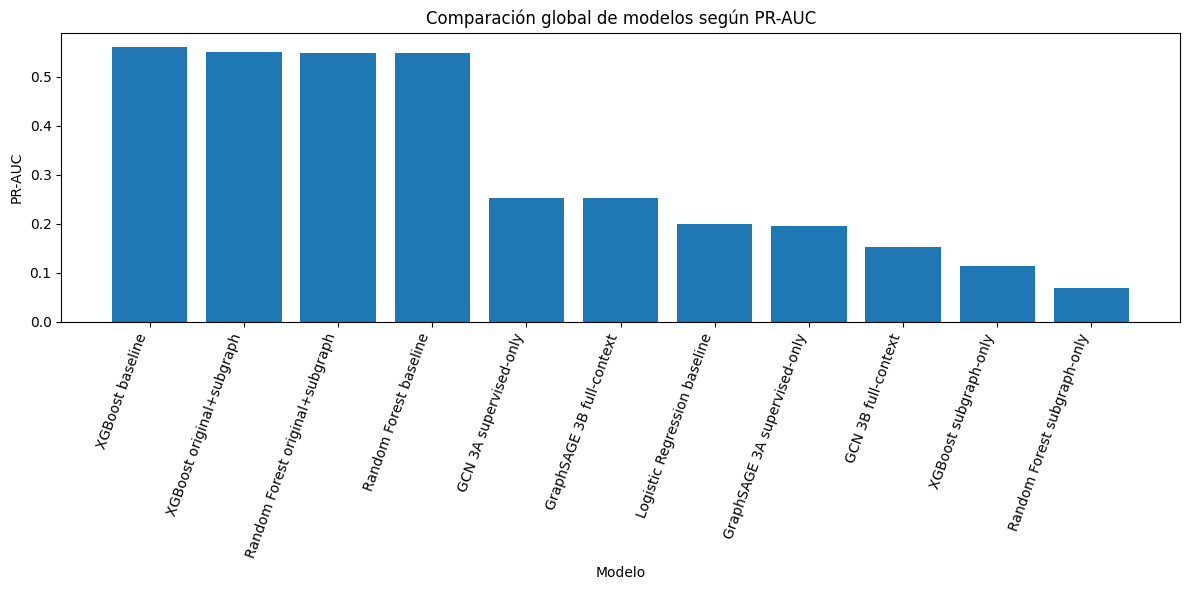

Guardado: /home/lucho/aml-gnn-tesis/reports/figures/level_5_pr_auc_model_comparison.png


In [20]:
# Gráfico PR-AUC
plot_df = level_5_comparison_df.sort_values("pr_auc", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(plot_df["model"], plot_df["pr_auc"])
plt.title("Comparación global de modelos según PR-AUC")
plt.xlabel("Modelo")
plt.ylabel("PR-AUC")
plt.xticks(rotation=70, ha="right")
plt.tight_layout()

fig_path = figures_dir / "level_5_pr_auc_model_comparison.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Guardado:", fig_path)

In [21]:
# Importancia de variables en XGBoost original + subgraph
feature_importance_df = pd.DataFrame({
    "feature": combined_feature_cols,
    "importance": xgb_combined_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
52,f_52,0.068367
99,f_99,0.067800
89,f_89,0.063402
45,f_45,0.047908
54,f_54,0.041833
39,f_39,0.041139
21,f_21,0.040060
162,f_162,0.037802
46,f_46,0.028862
58,f_58,0.025549


In [22]:
# Guardando importancia de variables
feature_importance_path = tables_dir / "xgb_original_plus_subgraph_feature_importance.csv"

feature_importance_df.to_csv(feature_importance_path, index=False)

print("Guardado:", feature_importance_path)

Guardado: /home/lucho/aml-gnn-tesis/reports/tables/xgb_original_plus_subgraph_feature_importance.csv
